In [4]:
from pathlib import Path
import sys
import pandas as pd

# Robust path setup - works regardless of execution directory
try:
    # For Jupyter notebooks, __file__ doesn't exist, so use Path.cwd()
    notebook_dir = Path.cwd()
    # Navigate up to project root from post_estimate_analysis
    project_root = notebook_dir.parent.parent.parent if 'post_estimate_analysis' in str(notebook_dir) else Path.cwd() / "../../.."
except:
    project_root = Path.cwd() / "../../.."

sys.path.insert(0, str(project_root / "src/Traction"))

import data_vis_utils as dv
import config

START_YEAR = 2015
END_YEAR = 2023

OUTPUT_DIR = Path(config.output_dir)

DOC_LEVEL_PATH = OUTPUT_DIR / "df_aiv.csv"

AGREEMENT_MONETARY_PATH = OUTPUT_DIR / "agreement_monetary_results.csv"
STANCE_MONETARY_PATH = OUTPUT_DIR / "stance_monetary_results.csv"

AGREEMENT_FISCAL_PATH = OUTPUT_DIR / "agreement_fiscal_results.csv"
STANCE_FISCAL_PATH = OUTPUT_DIR / "stance_fiscal_results.csv"

print(f"✓ Configuration loaded successfully")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Analysis period: {START_YEAR}-{END_YEAR}")

✓ Configuration loaded successfully
  Output directory: /data/home/xiong/data/Fund/CSR/Tractions/output
  Analysis period: 2015-2023


In [5]:
# Load document-level metadata

df_doc = pd.read_csv(DOC_LEVEL_PATH)
print(f"Loaded {len(df_doc):,} rows from {DOC_LEVEL_PATH}")
df_doc.head()

Loaded 1,177 rows from /data/home/xiong/data/Fund/CSR/Tractions/output/df_aiv.csv


,Print ISBN,filename_staff,text_staff,filename_buff,text_buff,text_sa,paragraphs_sa,paragraphs_bu,paragraphs_sr,paragraphs_av,...,buff_verified,staff_verified,"Extract text after "":""",Full Title,Subtitle,Title,Primary Country Code,Year from title,Publication Date,has_buff
0,9781513556642,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...","['25. Since the global financial crisis, Namib...",['My authorities appreciated the candid and pr...,"['1. Namibia is a small, upper middle-income c...",['9. The authorities share staff’s concerns an...,...,True,True,2015 Article IV Consultation-Press Release; S...,Namibia: 2015 Article IV Consultation-Press Re...,2015 Article IV Consultation-Press Release; St...,Namibia,NAM,2015.0,10/01/2015,1.0
1,9781475531671,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",NaN,NaN,"<html><body><sec id=""A01lev1sec5"">\n<title>Sta...",['34. The Uruguayan economy is decelerating gr...,NaN,['1. Uruguay’s economy performed strongly over...,['12. The authorities broadly agreed with staf...,...,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9781475586961,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['31. The Bulgarian economy and financial syst...,['The Bulgarian authorities highly appreciate ...,['1. Bulgaria’s reputation for macro-financial...,['9. The authorities broadly agreed with staff...,...,True,True,2015 Article IV Consultation-Staff Report; Pr...,Bulgaria: 2015 Article IV Consultation-Staff R...,2015 Article IV Consultation-Staff Report; Pre...,Bulgaria,BGR,2015.0,05/13/2015,1.0
3,9781513582290,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec3"">\n<title>Sta...",['30. The Norwegian economy has so far seen li...,"['On behalf of my Norwegian authorities, I wou...",['1. A sharp oil price drop materialized towar...,['12. The authorities generally agreed with th...,...,True,True,2015 Article IV Consultation - Press Release;...,Norway: 2015 Article IV Consultation - Press R...,2015 Article IV Consultation - Press Release; ...,Norway,NOR,2015.0,09/09/2015,1.0
4,9781513542218,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['35. The Angolan economy has been severely af...,['Angola has witnessed substantial improvement...,['1. Angola is a post-conflict country—decades...,['17. The authorities broadly agreed with staf...,...,True,True,2015 Article IV Consultation-Press Release; S...,Angola: 2015 Article IV Consultation-Press Rel...,2015 Article IV Consultation-Press Release; St...,Angola,AGO,2015.0,11/03/2015,1.0


In [6]:
# Filter to analysis window and build a clean integer `year`

df_doc = df_doc[df_doc["Year from title"].notna()].copy()
df_doc["year"] = pd.to_numeric(df_doc["Year from title"], errors="coerce").astype("Int64")

df_doc = dv.filter_year_range(
    df_doc,
    year_col="year",
    start_year=START_YEAR,
    end_year=END_YEAR,
)

In [7]:
# Income-group definitions live in dv (see data_vis_utils.py)

df_doc["income_group"] = df_doc["Primary Country Code"].apply(dv.classify_income_group_from_code)

counts = dv.compute_year_group_counts(
    df_doc,
    year_col="year",
    group_col="income_group",
    group_order=("AE", "EM", "LC"),
)


Total reports by income group:
income_group
AE    250
EM    225
LC    500
dtype: int64

Total reports: 975

Reports by year:
year
2015    113
2016    125
2017    129
2018    115
2019    128
2020     32
2021    117
2022    111
2023    105
dtype: int64


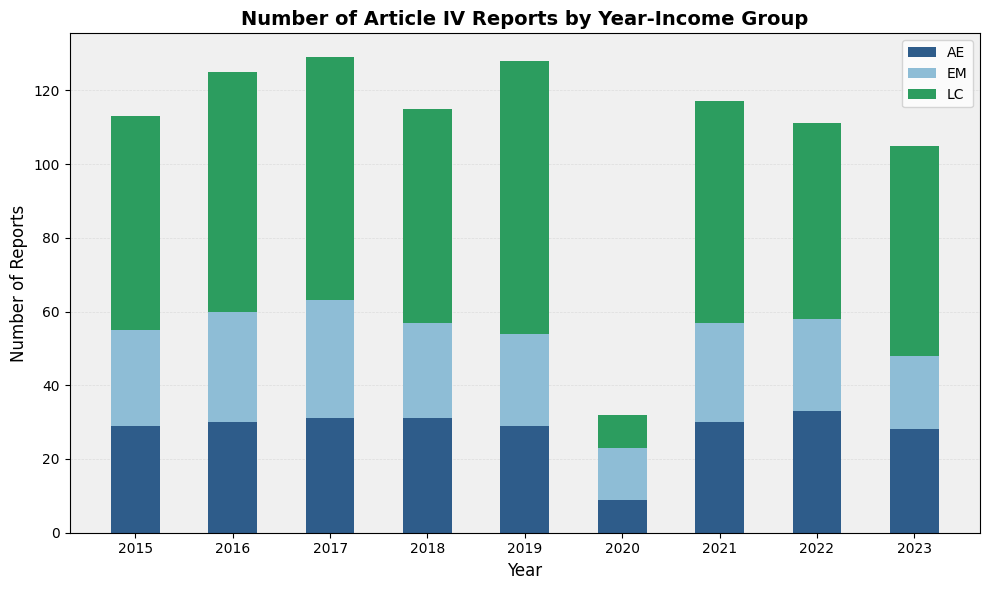

In [8]:
# Create stacked bar chart (via shared utility)
colors = {"AE": "#2E5C8A", "EM": "#8EBDD6", "LC": "#2C9D5F"}
dv.plot_stacked_counts_by_year(
    counts,
    group_order=("AE", "EM", "LC"),
    colors=colors,
    title="Number of Article IV Reports by Year-Income Group",
)
# Summary
print("\nTotal reports by income group:")
print(counts.sum())
print(f"\nTotal reports: {counts.sum().sum()}")
print("\nReports by year:")
print(counts.sum(axis=1))


In [10]:
# Load monetary agreement data

df_monetary_agreement = pd.read_csv(AGREEMENT_MONETARY_PATH)

df_monetary_agreement["income_group"] = df_monetary_agreement["country"].apply(
    dv.classify_income_group_from_country_name
)

# Filter to analysis window
df_monetary_agreement = dv.filter_year_range(
    df_monetary_agreement,
    year_col="year",
    start_year=START_YEAR,
    end_year=END_YEAR,
)

# Define "no disagreement" as agreement != 'disagreement exists'
df_monetary_agreement = dv.add_no_disagreement_flag(
    df_monetary_agreement,
    agreement_col="agreement",
    disagreement_value="disagreement exists",
    out_col="no_disagreement",
)

print(f"Total records: {len(df_monetary_agreement):,}")
print("\nAgreement distribution:")
print(df_monetary_agreement["agreement"].value_counts())
print("\nIncome group distribution:")
print(df_monetary_agreement["income_group"].value_counts())


Total records: 807

Agreement distribution:
agreement
mostly agree           422
irrelevant             196
disagreement exists    189
Name: count, dtype: int64

Income group distribution:
income_group
LIC    471
EM     175
AE     161
Name: count, dtype: int64


In [11]:
# % of reports without disagreement by year and income group

prop_df = dv.compute_no_disagreement_proportions_by_year(
    df_monetary_agreement,
    year_col="year",
    flag_col="no_disagreement",
    group_col="income_group",
    groups=("ALL", "AE", "EM", "LIC"),
)

print("Proportion of countries without monetary sector disagreement (%):")
print(prop_df.round(1))


Proportion of countries without monetary sector disagreement (%):
       ALL    AE    EM   LIC
2015  76.3  81.0  90.0  69.6
2016  74.7  66.7  71.4  78.0
2017  73.4  86.4  66.7  71.4
2018  78.7  75.0  68.4  83.6
2019  78.1  87.5  65.0  79.7
2020  63.0  85.7  40.0  70.0
2021  77.8  81.2  63.6  82.7
2022  79.8  85.7  72.7  80.4
2023  78.1  95.7  76.5  71.4


<Axes: title={'center': 'Proportion of Countries without Monetary Sector Disagreement'}, xlabel='Year', ylabel='Proportion (%)'>

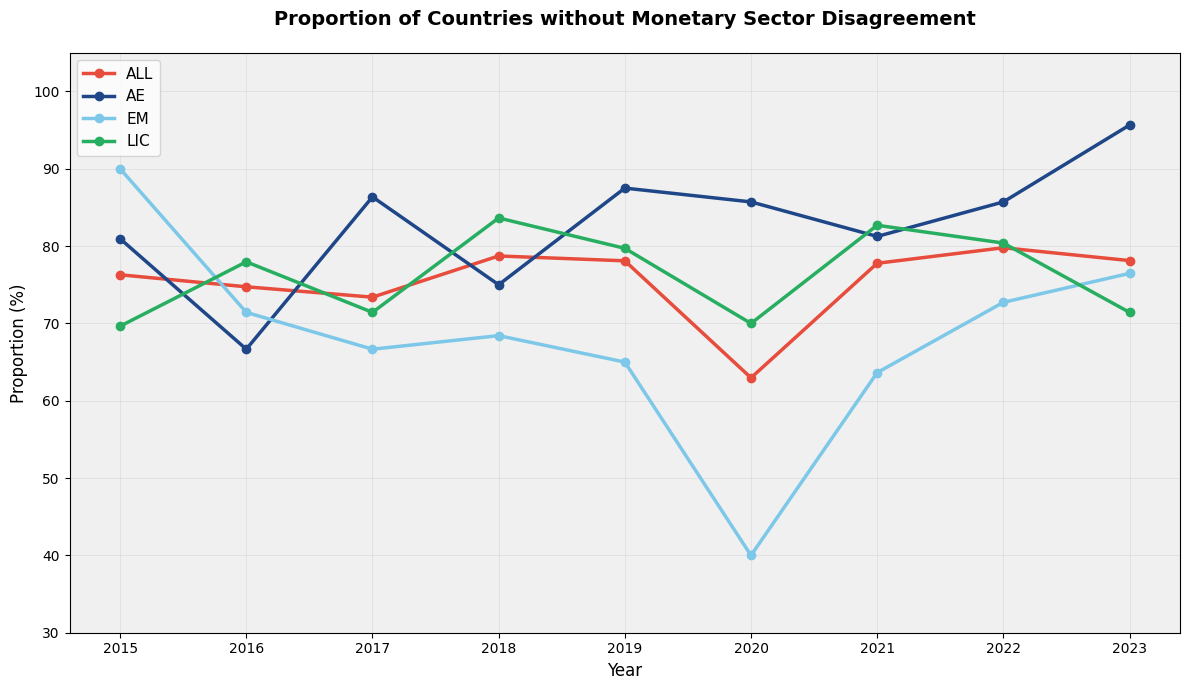

In [12]:
# Create line plot (via shared utility)

colors = {
    "ALL": "#E74C3C",  # Red
    "AE": "#1F4788",   # Dark Blue
    "EM": "#7DC8E8",   # Cyan/Sky Blue
    "LIC": "#27AE60",  # Green
}

dv.plot_group_lines_by_year(
    prop_df,
    groups=("ALL", "AE", "EM", "LIC"),
    colors=colors,
    title="Proportion of Countries without Monetary Sector Disagreement",
    ylim=(30, 105),
)


<Axes: title={'center': 'Monetary Agreement by Year'}, xlabel='Year'>

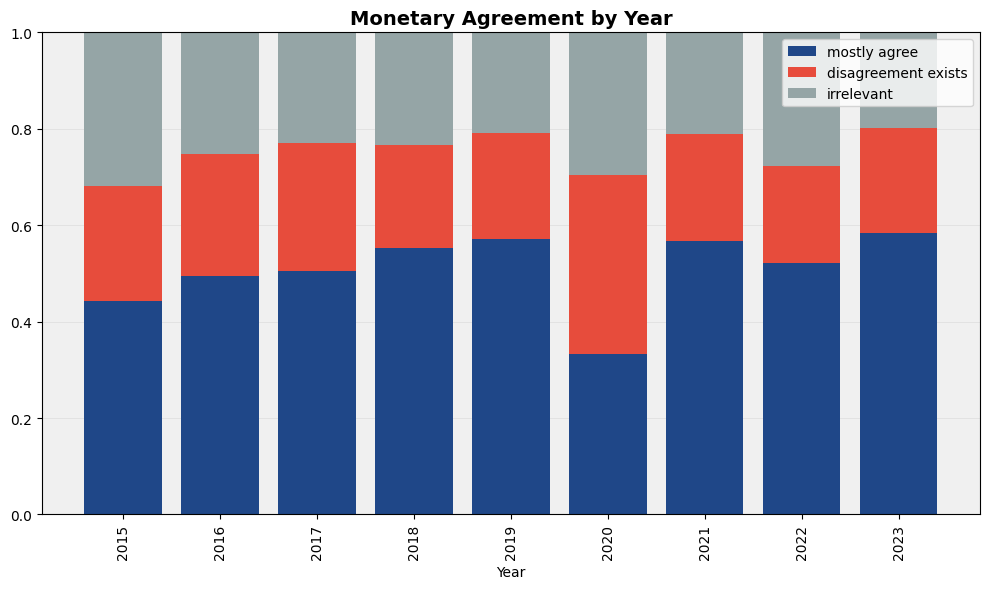

In [13]:
# Agreement distribution by year (stacked proportions)
# Recreates the stacked-bar style using df_monetary_agreement.

agreement_order = ("mostly agree", "disagreement exists", "irrelevant")

agreement_counts = (
    df_monetary_agreement.groupby(["year", "agreement"]).size().unstack(fill_value=0)
)
for a in agreement_order:
    if a not in agreement_counts.columns:
        agreement_counts[a] = 0
agreement_counts = agreement_counts[list(agreement_order)]

agreement_share = agreement_counts.div(agreement_counts.sum(axis=1), axis=0)

agreement_colors = {
    "mostly agree": "#1F4788",          # IMF dark blue
    "disagreement exists": "#E74C3C",   # IMF red
    "irrelevant": "#95A5A6",           # IMF grey
}

dv.plot_stacked_proportions_by_year(
    agreement_share,
    order=agreement_order,
    colors=agreement_colors,
    title="Monetary Agreement by Year",
    xlabel="Year",
    xtick_rotation=90,
)


In [14]:
# Parse disagreement areas and categorize them
# (categories are sector-specific; extraction/explode is reusable via dv)
categories = {
    "future policy direction": ["future policy direction", "forward guidance", "policy path"],
    "monetary policy operations": ["monetary policy operations", "policy operations"],
    "monetary policy framework": ["monetary policy framework", "policy framework"],
    "current policy stance": ["current policy stance", "policy stance"],
    "central bank communication": [
        "monetary policy communication",
        "central bank communication",
        "communication",
    ],
    "institutions": ["institutions", "independence", "governance"],
    "economic assessment": ["economic assessment"],
    "exchange rate policy": ["exchange rate policy", "exchange rate regime", "exchange rate flexibility"],
    "reserve requirements": ["reserve requirements"],
    "inflation target": ["inflation target"],
}

# Apply categorization + explode
_df_with_cats = dv.add_extracted_categories(
    df_monetary_agreement,
    text_col="disagreement_areas",
    categories=categories,
    out_col="categories",
)

df_disagree_long = dv.explode_categories(_df_with_cats, categories_col="categories", min_len=1)

print(f"Total disagreement records: {len(df_disagree_long)}")
print("\nCategory distribution:")
print(df_disagree_long["categories"].value_counts())


Total disagreement records: 364

Category distribution:
categories
future policy direction       144
monetary policy operations     68
monetary policy framework      67
current policy stance          34
exchange rate policy           14
central bank communication     13
economic assessment            12
inflation target                6
institutions                    5
reserve requirements            1
Name: count, dtype: int64


In [15]:
# Calculate % of reports with disagreement by area and year

all_categories = list(categories.keys())

total_reports_by_year = df_monetary_agreement.groupby("year").size()

disagree_pct = dv.compute_category_percentage_by_year(
    df_disagree_long,
    total_reports_by_year=total_reports_by_year,
    year_col="year",
    category_col="categories",
    category_order=all_categories,
)

print("Percentage of reports with disagreement by area:")
print(disagree_pct)


Percentage of reports with disagreement by area:
categories  future policy direction  monetary policy operations  \
year                                                              
2015                          14.43                       10.31   
2016                          20.00                       10.53   
2017                          20.18                        7.34   
2018                          18.09                        7.45   
2019                          17.14                        6.67   
2020                          29.63                       14.81   
2021                          14.44                        6.67   
2022                          18.09                        5.32   
2023                          16.67                       11.46   

categories  monetary policy framework  current policy stance  \
year                                                           
2015                             9.28                   6.19   
2016                 

<Axes: title={'center': '% of Reports with Disagreement by Area: Monetary'}, xlabel='Year', ylabel='% of Reports'>

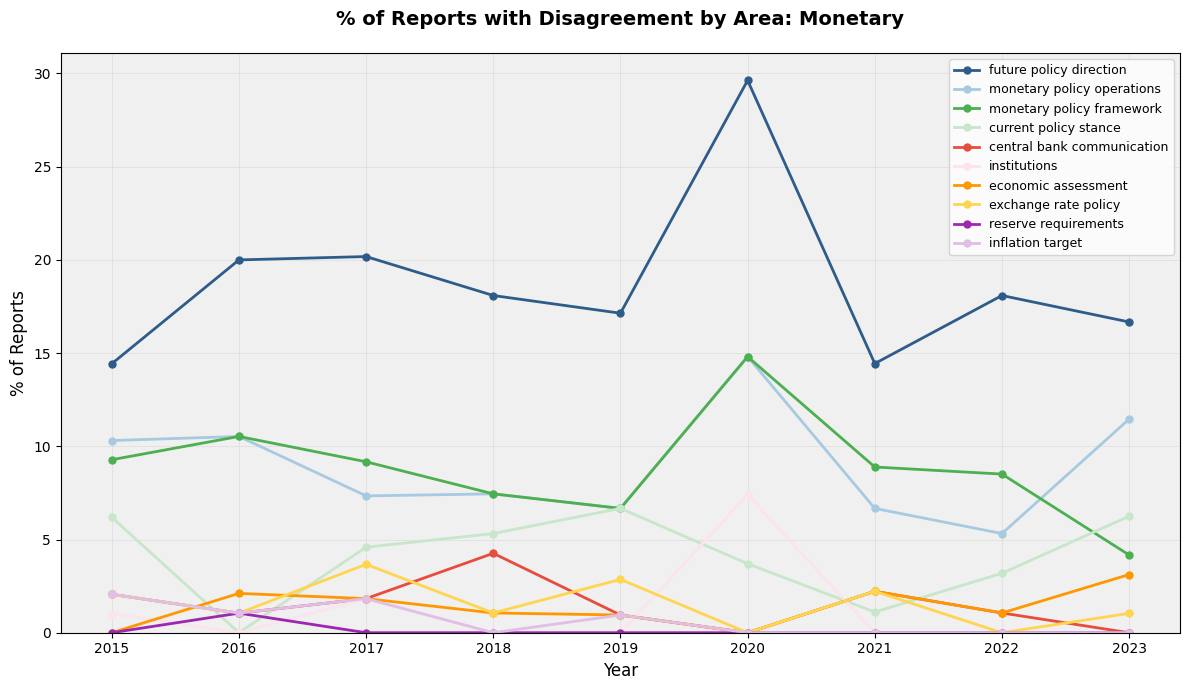

In [16]:
# Create multi-line plot for disagreement areas (via shared utility)
area_colors = {
    "future policy direction": "#2E5C8A",        # Dark blue
    "monetary policy operations": "#A8CAE1",     # Light blue
    "monetary policy framework": "#4CAF50",      # Green
    "current policy stance": "#C8E6C9",          # Light green
    "central bank communication": "#E74C3C",     # Red
    "institutions": "#FCE4EC",                   # Light pink
    "economic assessment": "#FF9800",            # Orange
    "exchange rate policy": "#FFD54F",           # Light orange/yellow
    "reserve requirements": "#9C27B0",           # Purple
    "inflation target": "#E1BEE7",               # Light purple
}

dv.plot_category_trends(
    disagree_pct,
    categories=all_categories,
    colors=area_colors,
    title="% of Reports with Disagreement by Area: Monetary",
)

In [18]:
# Load monetary stance data

df_monetary_stance = pd.read_csv(STANCE_MONETARY_PATH)
print(f"Total stance rows: {len(df_monetary_stance):,}")
df_monetary_stance.head()

Total stance rows: 1,444


,Print ISBN,topic,country,year,type,text,TEXT_AUTHOR,id,stance_current,stance_future
0,9781475517408,Monetary,Qatar,2015.0,staff,6. Monetary and credit conditions remain accom...,IMF staff,0,accommodative,no change
1,9781475518375,Monetary,Tonga,2015.0,staff,17. Tonga has adopted an informal inflation re...,IMF staff,1,accommodative,no change
2,9781475518375,Monetary,Tonga,2015.0,buff,19. The authorities agreed with staff’s views ...,country authority,2,unclear,no change
3,9781475519679,Monetary,Thailand,2015.0,staff,21. Policy stance. While the current monetary ...,IMF staff,3,accommodative,loosening bias
4,9781475519679,Monetary,Thailand,2015.0,buff,23. Authorities’ views. The authorities viewed...,country authority,4,accommodative,no change


In [20]:
# Pivot stance results to wide format (via shared utility)

df_monetary_stance_wide = dv.pivot_stance_wide(df_monetary_stance)
df_monetary_stance_wide.head()


,Print ISBN,topic,country,year,country_authority_stance_current,imf_staff_stance_current,country_authority_stance_future,imf_staff_stance_future
0,9781475515039,Monetary,Uruguay,2015.0,restrictive,restrictive,no change,no change
1,9781475517231,Monetary,United Kingdom,2016.0,neutral,accommodative,unclear,no change
2,9781475517408,Monetary,Qatar,2015.0,NaN,accommodative,NaN,no change
3,9781475517682,Monetary,Jamaica,2016.0,unclear,neutral,loosening bias,loosening bias
4,9781475517927,Monetary,Hungary,2016.0,accommodative,accommodative,loosening bias,loosening bias


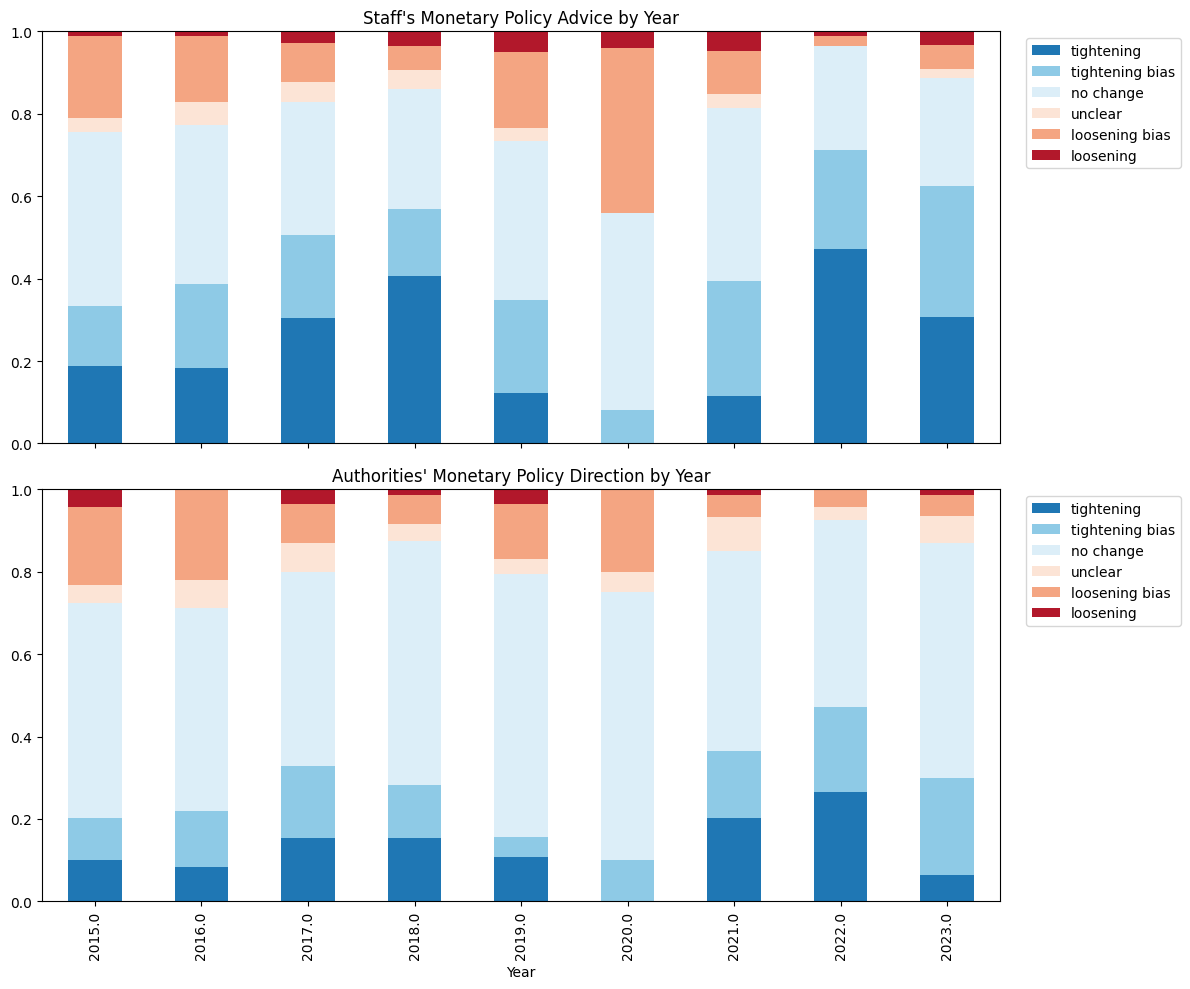

In [21]:
# Stacked stance distributions over time (same color scheme as screenshot)

import matplotlib.pyplot as plt

stance_order = (
    "tightening",
    "tightening bias",
    "no change",
    "unclear",
    "loosening bias",
    "loosening",
)

stance_colors = {
    "tightening": "#1F77B4",        # dark blue
    "tightening bias": "#8ECAE6",   # light blue
    "no change": "#DCEEF8",         # very light blue
    "unclear": "#FCE4D6",           # pale peach
    "loosening bias": "#F4A582",    # salmon
    "loosening": "#B2182B",         # deep red
}


def _stance_share_by_year(df_wide: pd.DataFrame, *, year_col: str, stance_col: str) -> pd.DataFrame:
    counts = df_wide.groupby([year_col, stance_col]).size().unstack(fill_value=0)
    for s in stance_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[list(stance_order)]
    return counts.div(counts.sum(axis=1), axis=0)


staff_share = _stance_share_by_year(df_monetary_stance_wide, year_col="year", stance_col="imf_staff_stance_future")
auth_share = _stance_share_by_year(
    df_monetary_stance_wide,
    year_col="year",
    stance_col="country_authority_stance_future",
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

staff_share.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[stance_colors[c] for c in staff_share.columns],
    edgecolor="none",
)
ax1.set_title("Staff's Monetary Policy Advice by Year")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_ylim(0, 1.0)
ax1.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

auth_share.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[stance_colors[c] for c in auth_share.columns],
    edgecolor="none",
)
ax2.set_title("Authorities' Monetary Policy Direction by Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("")
ax2.set_ylim(0, 1.0)
ax2.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()


<Axes: title={'center': "IMF Advice Compared to Authorities' Monetary Policy Direction"}, xlabel='Year'>

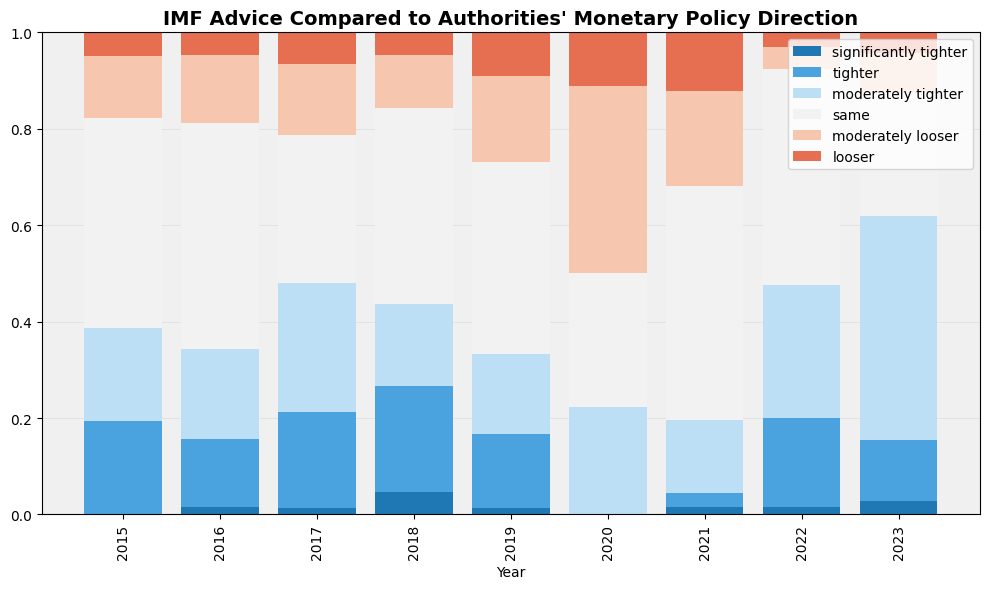

In [22]:
# IMF advice vs authorities: policy direction (via shared utilities)

imf_col = "imf_staff_stance_future"
auth_col = "country_authority_stance_future"

share = dv.compute_imf_vs_authority_share(
    df_monetary_stance_wide,
    year_col="year",
    imf_col=imf_col,
    auth_col=auth_col,
    start_year=2015,
    end_year=2023,
)

dv.plot_stacked_proportions_by_year(
    share,
    title="IMF Advice Compared to Authorities' Monetary Policy Direction",
)


In [23]:
# -----------------------------
# Fiscal sector: Agreement
# -----------------------------

df_fiscal_agreement = pd.read_csv(AGREEMENT_FISCAL_PATH)

df_fiscal_agreement["income_group"] = df_fiscal_agreement["country"].apply(
    dv.classify_income_group_from_country_name
)

# Filter to analysis window

df_fiscal_agreement = dv.filter_year_range(
    df_fiscal_agreement,
    year_col="year",
    start_year=START_YEAR,
    end_year=END_YEAR,
)

# Define "no disagreement" as agreement != 'disagreement exists'

df_fiscal_agreement = dv.add_no_disagreement_flag(
    df_fiscal_agreement,
    agreement_col="agreement",
    disagreement_value="disagreement exists",
    out_col="no_disagreement",
)

print(f"Total fiscal agreement records: {len(df_fiscal_agreement):,}")
print("\nAgreement distribution:")
print(df_fiscal_agreement["agreement"].value_counts())
print("\nIncome group distribution:")
print(df_fiscal_agreement["income_group"].value_counts())


Total fiscal agreement records: 971

Agreement distribution:
agreement
mostly agree           597
disagreement exists    365
irrelevant               9
Name: count, dtype: int64

Income group distribution:
income_group
LIC    582
AE     204
EM     185
Name: count, dtype: int64


Proportion of countries without fiscal-sector disagreement (%):
       ALL    AE    EM   LIC
2015  54.9  52.2  45.0  58.6
2016  58.9  34.8  72.0  61.8
2017  62.2  69.2  56.0  61.8
2018  58.3  57.7  50.0  60.9
2019  60.2  56.5  63.6  60.2
2020  71.9  77.8  81.8  58.3
2021  66.4  84.0  50.0  65.2
2022  68.5  57.7  60.9  75.8
2023  68.6  56.5  76.5  70.8


<Axes: title={'center': 'Proportion of Countries without Fiscal Sector Disagreement'}, xlabel='Year', ylabel='Proportion (%)'>

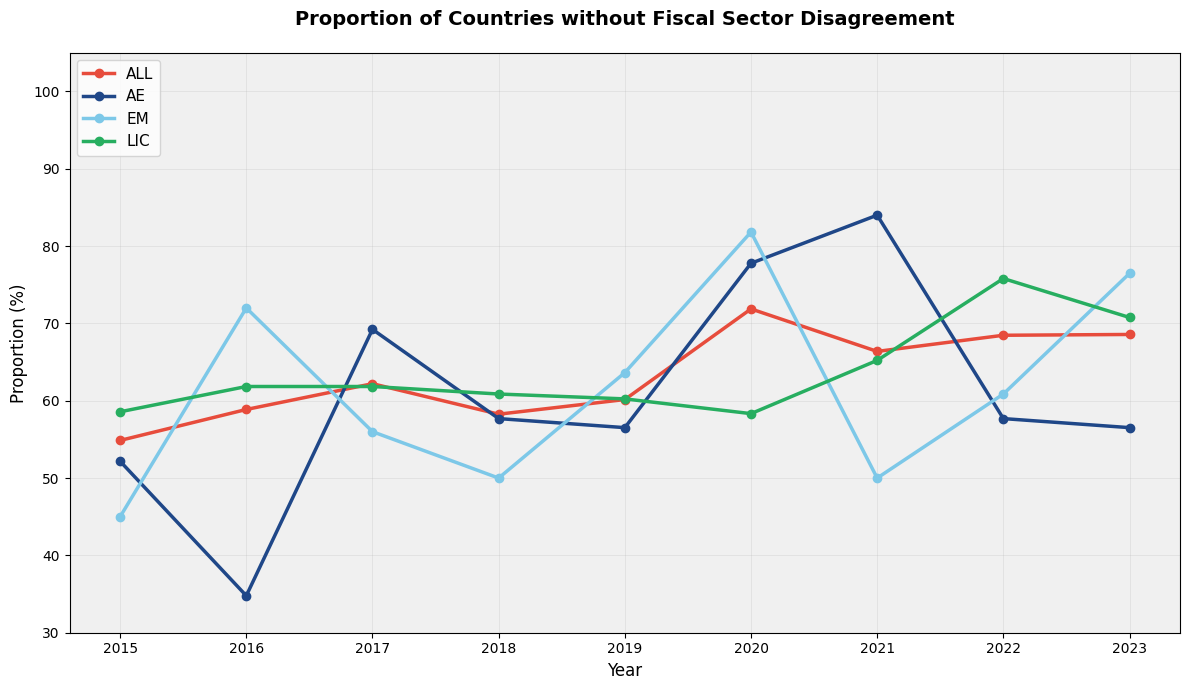

In [24]:
# % of reports without fiscal-sector disagreement by year and income group

prop_fiscal = dv.compute_no_disagreement_proportions_by_year(
    df_fiscal_agreement,
    year_col="year",
    flag_col="no_disagreement",
    group_col="income_group",
    groups=("ALL", "AE", "EM", "LIC"),
)

print("Proportion of countries without fiscal-sector disagreement (%):")
print(prop_fiscal.round(1))

colors = {
    "ALL": "#E74C3C",  # Red
    "AE": "#1F4788",   # Dark Blue
    "EM": "#7DC8E8",   # Cyan/Sky Blue
    "LIC": "#27AE60",  # Green
}

dv.plot_group_lines_by_year(
    prop_fiscal,
    groups=("ALL", "AE", "EM", "LIC"),
    colors=colors,
    title="Proportion of Countries without Fiscal Sector Disagreement",
    ylim=(30, 105),
)


Total fiscal disagreement records: 839

Category distribution:
categories
fiscal revenue                 155
near-term policy direction     149
fiscal expenditure             130
government debt & financing    130
medium-term fiscal stance      129
fiscal framework                85
economic assessment             42
political commitment            19
Name: count, dtype: int64

Percentage of reports with fiscal disagreement by area:
categories  near-term policy direction  medium-term fiscal stance  \
year                                                                
2015                             19.47                      15.93   
2016                             19.35                      12.90   
2017                             15.75                      13.39   
2018                             15.65                      19.13   
2019                             13.28                      13.28   
2020                             12.50                      12.50   
2021       

<Axes: title={'center': '% of Reports with Disagreement: Fiscal'}, xlabel='Year', ylabel='% of Reports'>

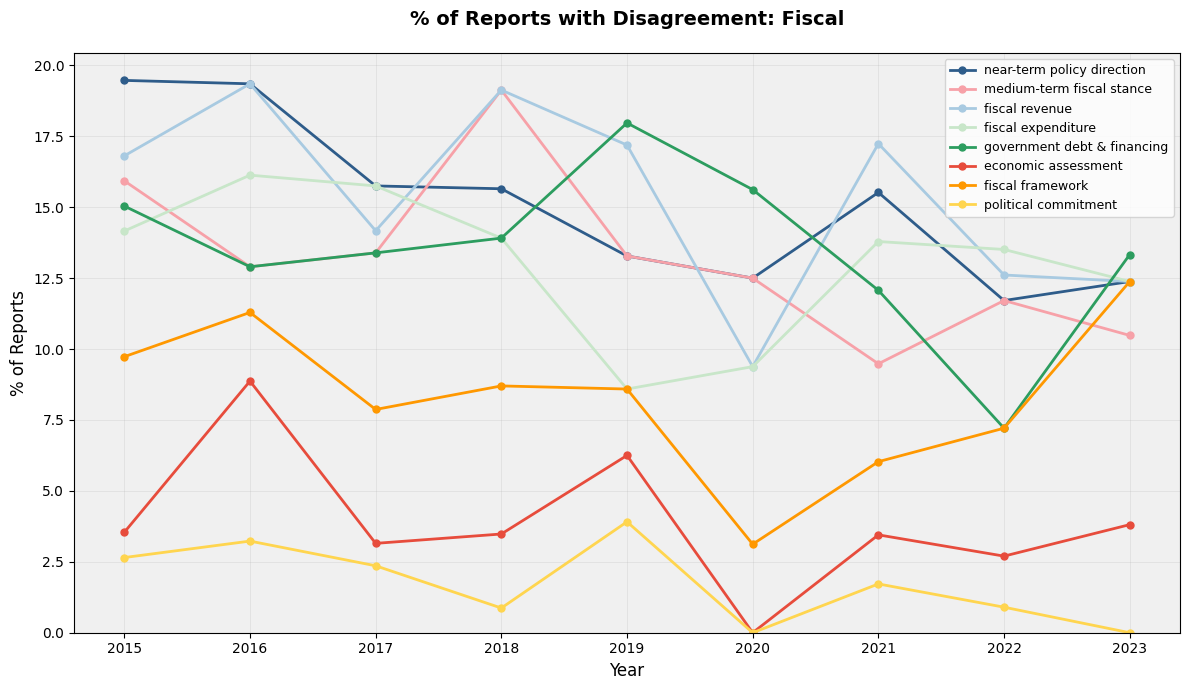

In [25]:
# Disagreement areas (fiscal): categorize + trend
# Categories aligned with the fiscal disagreement chart legend.

fiscal_categories = {
    "near-term policy direction": [
        "near-term",
        "short term",
        "frontload",
        "front-loaded",
        "immediate",
        "next year",
        "this year",
        "fiscal tightening",
        "fiscal easing",
        "pace of",
    ],
    "medium-term fiscal stance": [
        "medium-term",
        "medium term",
        "over the medium term",
        "fiscal stance",
        "fiscal adjustment path",
        "gradual",
        "consolidation path",
        "trajectory",
    ],
    "fiscal revenue": [
        "revenue",
        "tax",
        "vat",
        "gst",
        "income tax",
        "corporate tax",
        "tax base",
        "tax administration",
        "collection",
        "customs",
    ],
    "fiscal expenditure": [
        "expenditure",
        "spending",
        "current spending",
        "wage bill",
        "public wage",
        "subsid",
        "transfer",
        "social spending",
        "pension",
        "capital spending",
        "public investment",
        "infrastructure",
    ],
    "government debt & financing": [
        "debt",
        "borrowing",
        "financing",
        "rollover",
        "refinancing",
        "debt sustainability",
        "debt dynamics",
        "gross financing needs",
        "bond",
        "issuance",
    ],
    "economic assessment": [
        "economic outlook",
        "growth",
        "inflation",
        "output gap",
        "macroeconomic",
        "baseline",
        "downside risk",
        "risk",
        "shock",
        "forecast",
    ],
    "fiscal framework": [
        "fiscal rule",
        "framework",
        "mtbf",
        "medium-term budget framework",
        "fiscal responsibility",
        "escape clause",
        "budget process",
        "transparency",
    ],
    "political commitment": [
        "political",
        "commitment",
        "ownership",
        "parliament",
        "election",
        "public support",
        "social consensus",
        "implementation",
    ],
}

_df_fiscal_with_cats = dv.add_extracted_categories(
    df_fiscal_agreement,
    text_col="disagreement_areas",
    categories=fiscal_categories,
    out_col="categories",
)

df_fiscal_disagree_long = dv.explode_categories(
    _df_fiscal_with_cats,
    categories_col="categories",
    min_len=1,
)

print(f"Total fiscal disagreement records: {len(df_fiscal_disagree_long):,}")
print("\nCategory distribution:")
print(df_fiscal_disagree_long["categories"].value_counts())

all_fiscal_categories = list(fiscal_categories.keys())

total_fiscal_reports_by_year = df_fiscal_agreement.groupby("year").size()

fiscal_disagree_pct = dv.compute_category_percentage_by_year(
    df_fiscal_disagree_long,
    total_reports_by_year=total_fiscal_reports_by_year,
    year_col="year",
    category_col="categories",
    category_order=all_fiscal_categories,
)

print("\nPercentage of reports with fiscal disagreement by area:")
print(fiscal_disagree_pct)

# Plot trend lines with explicit colors (otherwise all default to black).

fiscal_area_colors = {
    "near-term policy direction": "#2E5C8A",
    "fiscal revenue": "#A8CAE1",
    "government debt & financing": "#2C9D5F",
    "fiscal expenditure": "#C8E6C9",
    "economic assessment": "#E74C3C",
    "medium-term fiscal stance": "#F7A1A8",
    "fiscal framework": "#FF9800",
    "political commitment": "#FFD54F",
}

dv.plot_category_trends(
    fiscal_disagree_pct,
    categories=all_fiscal_categories,
    colors=fiscal_area_colors,
    title="% of Reports with Disagreement: Fiscal",
)


In [26]:
# -----------------------------
# Fiscal sector: Stance
# -----------------------------

df_fiscal_stance = pd.read_csv(STANCE_FISCAL_PATH)
print(f"Total fiscal stance rows: {len(df_fiscal_stance):,}")
df_fiscal_stance.head()


Total fiscal stance rows: 1,953


,Print ISBN,topic,country,year,type,text,author_type,type_possessive,verb,examples,explanation,id,reason,stance_near_term
0,9781475517408,Fiscal,Qatar,2015.0,buff,17. The authorities noted that fiscal policies...,a country's authorities,country's authorities',planned,Example 1: Country: Tunisia; Year: 2015; Text:...,Note that the near-term policy direction plann...,0,The authorities emphasize maintaining restrain...,no change
1,9781475517408,Fiscal,Qatar,2015.0,staff,5. The budget continues to post large surpluse...,IMF staff,IMF staff's,recommended,Example 1: Country: Tunisia; Year: 2015; Text:...,Note that the near-term policy direction recom...,1,The text emphasizes that due to a drop in oil ...,unclear
2,9781475518375,Fiscal,Tonga,2015.0,staff,3. Traction. The authorities have made progres...,IMF staff,IMF staff's,recommended,Example 1: Country: Tunisia; Year: 2015; Text:...,Note that the near-term policy direction recom...,2,The staff recommends containing near-term spen...,tightening
3,9781475518375,Fiscal,Tonga,2015.0,buff,12. The authorities broadly agreed with staff’...,a country's authorities,country's authorities',planned,Example 1: Country: Tunisia; Year: 2015; Text:...,Note that the near-term policy direction plann...,3,The text outlines concrete fiscal consolidatio...,tightening
4,9781475519679,Fiscal,Thailand,2015.0,staff,"11. Recent developments. In 2014, the fiscal p...",IMF staff,IMF staff's,recommended,Example 1: Country: Tunisia; Year: 2015; Text:...,Note that the near-term policy direction recom...,4,IMF staff explicitly states that the short-ter...,loosening


In [36]:
# Pivot stance results to wide format (via shared utility)

df_fiscal_stance_wide = dv.pivot_stance_wide(df_fiscal_stance,author_col= "author_type",stance_cols = ["stance_near_term"])
# Rename columns to match expected naming convention
df_fiscal_stance_wide = df_fiscal_stance_wide.rename(columns={
    "a_country_s_authorities_stance_near_term": "country_authority_stance_future",
    "imf_staff_stance_near_term": "imf_staff_stance_future"
})

df_fiscal_stance_wide.head()


,Print ISBN,topic,country,year,country_authority_stance_future,imf_staff_stance_future
0,9781475515039,Fiscal,Uruguay,2015.0,tightening,tightening
1,9781475517231,Fiscal,United Kingdom,2016.0,tightening,loosening bias
2,9781475517408,Fiscal,Qatar,2015.0,no change,unclear
3,9781475517675,Fiscal,Ireland,2016.0,unclear,loosening bias
4,9781475517682,Fiscal,Jamaica,2016.0,tightening,no change


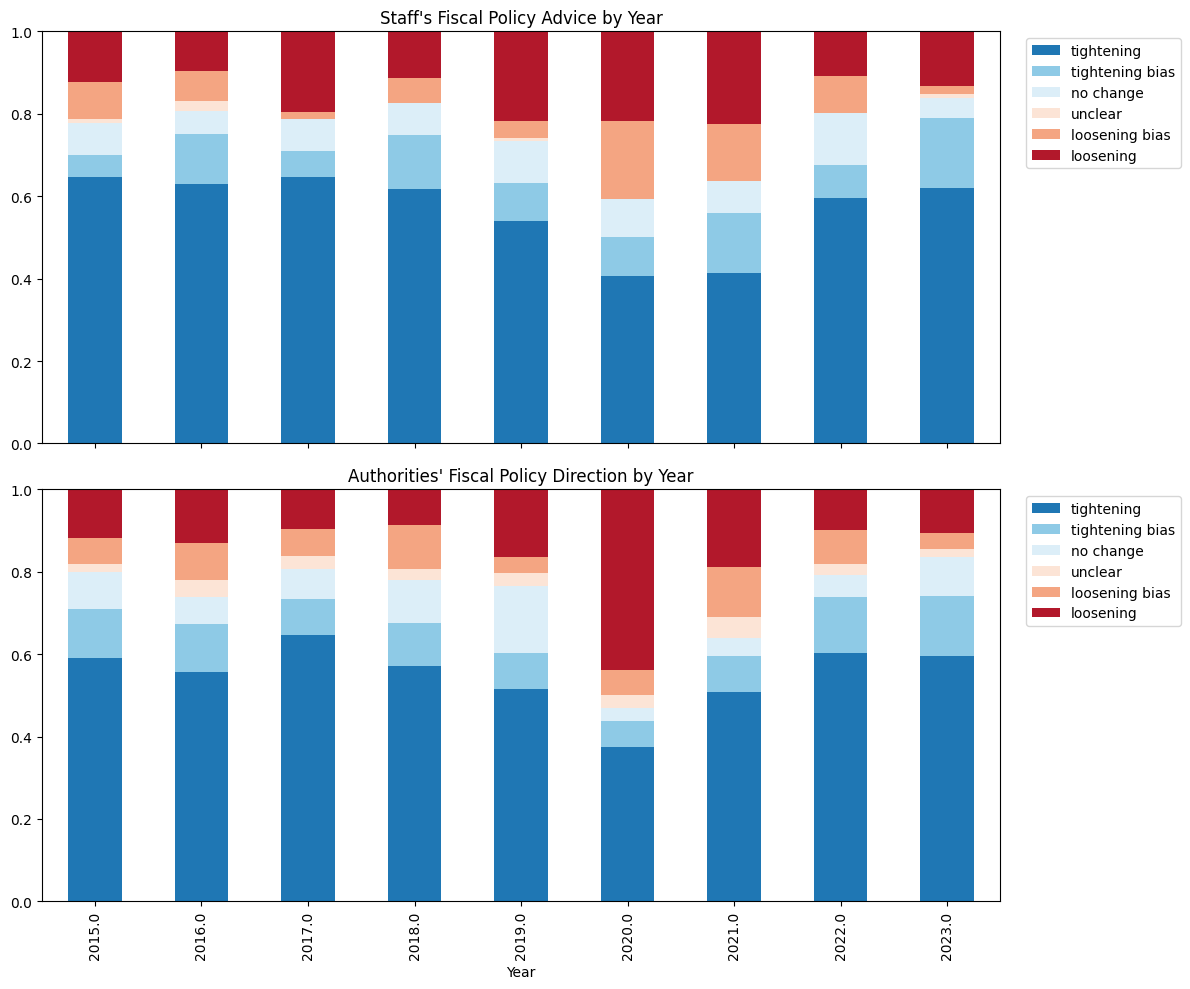

In [37]:
import matplotlib.pyplot as plt

stance_order = (
    "tightening",
    "tightening bias",
    "no change",
    "unclear",
    "loosening bias",
    "loosening",
)

stance_colors = {
    "tightening": "#1F77B4",        # dark blue
    "tightening bias": "#8ECAE6",   # light blue
    "no change": "#DCEEF8",         # very light blue
    "unclear": "#FCE4D6",           # pale peach
    "loosening bias": "#F4A582",    # salmon
    "loosening": "#B2182B",         # deep red
}


def _stance_share_by_year(df_wide: pd.DataFrame, *, year_col: str, stance_col: str) -> pd.DataFrame:
    counts = df_wide.groupby([year_col, stance_col]).size().unstack(fill_value=0)
    for s in stance_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[list(stance_order)]
    return counts.div(counts.sum(axis=1), axis=0)


staff_share = _stance_share_by_year(df_fiscal_stance_wide, year_col="year", stance_col="imf_staff_stance_future")
auth_share = _stance_share_by_year(
    df_fiscal_stance_wide,
    year_col="year",
    stance_col="country_authority_stance_future",
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

staff_share.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[stance_colors[c] for c in staff_share.columns],
    edgecolor="none",
)
ax1.set_title("Staff's Fiscal Policy Advice by Year")
ax1.set_xlabel("")
ax1.set_ylabel("")
ax1.set_ylim(0, 1.0)
ax1.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

auth_share.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[stance_colors[c] for c in auth_share.columns],
    edgecolor="none",
)
ax2.set_title("Authorities' Fiscal Policy Direction by Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("")
ax2.set_ylim(0, 1.0)
ax2.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

<Axes: title={'center': "IMF Advice Compared to Authorities' Fiscal Policy Direction"}, xlabel='Year'>

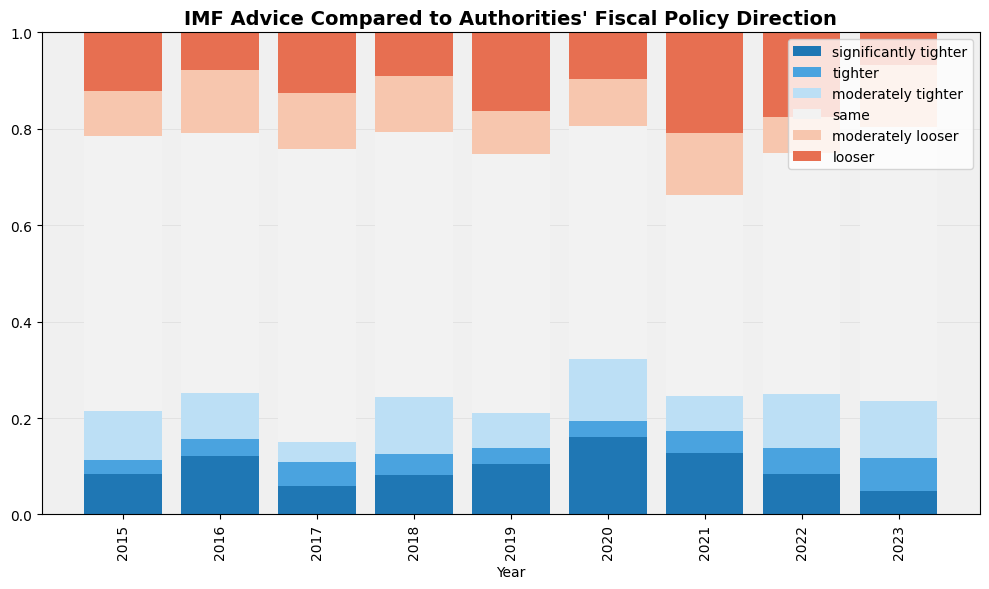

In [38]:
# IMF advice vs authorities: fiscal policy direction (stance_future)

imf_col = "imf_staff_stance_future"
auth_col = "country_authority_stance_future"

share_fiscal = dv.compute_imf_vs_authority_share(
    df_fiscal_stance_wide,
    year_col="year",
    imf_col=imf_col,
    auth_col=auth_col,
    start_year=START_YEAR,
    end_year=END_YEAR,
)

dv.plot_stacked_proportions_by_year(
    share_fiscal,
    title="IMF Advice Compared to Authorities' Fiscal Policy Direction",
)
